In [ ]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

# This code prepares the files for the peaks detection visualisation code 
## - Do the peak detection with Laplacian (many sigma values) and Slope (3 or 4  rings)
## - If more than one size of the detection box is wanted, the code must be rerunned
## - Calculate the detection level files using many sizes of the background box 
## - It will remove nan and replace stars by median value when needed
## - In this version star mask = 1 for stars

## Version 2023-01-04  for NGC4490  (do not use Detection.py and utils.py)


In [1]:
import numpy as np
import astropy.io.fits as fits
from scipy.ndimage import median_filter, uniform_filter, minimum_filter, maximum_filter, convolve
from scipy.ndimage import gaussian_laplace
from scipy import stats

import os
import json

from time import perf_counter as clock
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## Answer the following questions 

In [2]:
############### Enter files names (path):
#jsonfile = '../data.json'
#data_paths_dict = json.load(open(jsonfile))

### amplitude map for peak detection and detection level

field = 'NW'
distance = 100

directory = f'degraded-fits/{field}/'

amp_path = directory+f'{field}_amp_sim_{distance}Mpc.fits'
### A good file for the coordinates
coo_path =  directory+f'{field}_amp_sim_{distance}Mpc.fits'
### A good file for the header
hea_path =  directory+f'{field}_amp_sim_{distance}Mpc.fits'

#### Ha flux (for comparison in the peak detection)
# flu_path = '../../M33-F5/M33F5-Haflux.fits'

### noise (you prepare before)
noi_path = directory+f'{field}_noise_sim_{distance}Mpc.fits'

### stars' mask (you prepare before)
sta_path = noi_path
### specify is stars are 0 or 1 in your mask and maximum star radius used
starvalue = 0
starmaxrad = 100

### SN3 data cube AND an average sky spectrum --- If none, leave = ''
cub_path = '' #data_paths_dict['cube_SN3'] 
sky_path = '' #data_paths_dict['sky_SN3_spec'] 

### HST (2 is the max -- If none, leave = ''   
###     if you change your mind, you can edit the input file after...)
hst_vi_path = '' #'/home/carmelle/Bureau/NGC4449/0-DATA/hst_13364_56_wfc3_uvis_total_drz.fits' 
hst_ha_path = '' #'../HST_Maps/hst_13773_19_wfc3_uvis_f657n_icnk19_drc.fits' 

### velocity, velocity dispersion, SII/Ha * sigma...  --- If none, leave = ''
vel_path = ''
sig_path = ''
shs_path = ''

############### Give the following info:

### Section of the image to be studied: x_init, x_final, y_init, y_final - must avoid at least 50 pixels around
if distance == 0.84:
    xi, xf, yi, yf = 50, 2000, 50, 2000  #considering the area measured by Laurent
elif distance == 5:
     xi, xf, yi, yf = 10, 360, 10, 360
elif distance == 10:
     xi, xf, yi, yf = 5, 170, 5, 170
elif distance == 20:
     xi, xf, yi, yf = 3, 85, 3, 85
elif distance == 35:
        xi, xf, yi, yf = 3, 48, 3, 48
elif distance == 50:
        xi, xf, yi, yf = 1, 32, 1, 32
elif distance == 100:
        xi, xf, yi, yf = 1, 16, 1, 16
# else:
#     xi, xf, yi, yf = max(int(10/(distance/0.84)), 10), max(int(10/(distance/0.84)),10), int(2000/(distance/0.84)), int(2000/(distance/0.84))
print('x_init, x_final, y_init, y_final: ',xi, xf, yi, yf)
### Central pixels (for first display...)
xcen = xi + int((xf-xi)/2.)
ycen = yi + int((yf-yi)/2.)

### size of the peak detection box :  1=3x3   2=5x5   3=7x7    etc.
sizedet = 1

### For the laplacien: specify 7 (not more, not less) values of sigma you will want to see
### but it will be calculated from sigma = 1 to 2.0 (by 0.1) automaticaly so you can edit the param file...
lapsigma_range = np.array([1.2, 1.4, 1.5, 1.6, 1.7, 1.8, 2.0])
    
### For the slope: you must specify if you want 3 or 4 rings
nringslo = 3

### For the BG: specify 5 (not more, not less) values of size you will want to see
### but it will be calculated from 6 to 40 (by 2) automaticaly so you can edit the param file...
localemis_range = np.array([22, 26, 30, 34, 38])   

### Rootname for the output file to be called by the visualisation code:
rootout = 'param'

### Folder for new files (if already exits, files will be replaced)
Folder_u = f'data_for_visualisation_{distance}/'

print('All done')

x_init, x_final, y_init, y_final:  1 16 1 16
All done


In [3]:
# fits.getdata(sta_path)

In [4]:
# Code tests given vales
# Section of the image
if xi < 10 or yi < 10 or xf > 2048-10 or yf > 2064-10: 
    print('Please correct image section avoiding 50 pixels at the edge' )
    
# Detection box
defaultsiz=[1,2,3]
if sizedet not in defaultsiz: print('Please correct your detection box size')

#Sigma laplacian
if len(lapsigma_range) != 7: print('You must specify 7 values for sigma_Lap - please correct')
defaultsig = [1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
for ii in lapsigma_range: 
    if ii not in defaultsig: print('sigma_lap = ', ii, ' is bad - please correct this value')

# Slope rings
defaultring=[3,4]
if nringslo not in defaultring: print('Please correct the number of rings for the Solpe')

#BG boxes
if len(localemis_range) != 5: print('You must specify 5 values for the BG box - please correct')
defaultbg = [6, 10, 14, 20, 30]
for ii in localemis_range:
    if ii not in defaultbg: print('BG box    = ', ii, ' is bad - please correct this value')

print('Check for values done')

Please correct image section avoiding 50 pixels at the edge
BG box    =  22  is bad - please correct this value
BG box    =  26  is bad - please correct this value
BG box    =  34  is bad - please correct this value
BG box    =  38  is bad - please correct this value
Check for values done


# Preparing files - with no NAN...¶

In [5]:
def getchecknan(path):
    mapin  = fits.getdata(path)
    mapout = np.copy(mapin)
    nbnan0 = np.count_nonzero(np.isnan(mapin[yi:yf,xi:xf]))
    if nbnan0 != 0:
        yn,xn = np.where(np.isnan(mapin[yi:yf,xi:xf]))
        yn,xn = yn+yi, xn+xi
        for i in range(nbnan0):
            mapout[yn[i],xn[i]]=np.nanmedian(mapin[yn[i]-1:yn[i]+2,xn[i]-1:xn[i]+2]) 
    nbnan = np.count_nonzero(np.isnan(mapout[yi:yf,xi:xf]))
    print('NAN for ',path, ' : ', nbnan0, ' -> ', nbnan)
    return(mapout)
    
def makefinal(nan0,infile):
    if nan0 == 1: infile[sta_map==starvalue] = np.nan  
    if nan0 == 0: infile[sta_map==starvalue] = 0 
    outfile            = np.zeros(infile.shape)/0
    outfile[yi+1:yf-1,xi+1:xf-1] = np.copy(infile[yi+1:yf-1,xi+1:xf-1])
    return(outfile)


### Code creates/checks a folder for files
if os.path.isdir(Folder_u) == False:
    os.mkdir(Folder_u)
    print('Folder created: ', Folder_u )
else:
    print('Folder exists already: ', Folder_u )
    
print() 
### Code gets good header info
bidon,header_info = fits.getdata(hea_path, header=True)

### Code opens files and replaces NAN within [yi:yf,xi:xf] with median background +/- 1 pix 
print('Opening files and removing NAN within image section')
amp_e_map      = getchecknan(amp_path)
# flu_e_map      = getchecknan(flu_path)
noi_e_map      = getchecknan(noi_path)
sta_map        = getchecknan(sta_path)

print()
### Code saves the Ha amplitude file with noNAN
amp_nonan_name = f'M33_{distance}_Ha_amp_nonan'
fits.writeto(f'{Folder_u}{amp_nonan_name}.fits', amp_e_map, header_info, overwrite=True)
amp_nonan_path = f'{Folder_u}{amp_nonan_name}.fits'
print('Amplitude file with no NAN: ',amp_nonan_path)

print()
### Code replaces stars with median in background square +/- starmaxrad +2
### (usualy a maximum radius of stars is 25 pix)
print('Replacing stars with median...')
radstar = starmaxrad+2
yn,xn = np.where(sta_map[yi:yf,xi:xf]==starvalue)   
yn,xn = yn+yi, xn+xi
amp_m_map=np.copy(amp_e_map)
# flu_m_map=np.copy(flu_e_map)
noi_m_map=np.copy(noi_e_map)
for i in range(len(yn)):
    amp_m_map[yn[i],xn[i]] = np.nanmedian(amp_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 
    # flu_m_map[yn[i],xn[i]] = np.nanmedian(flu_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 
    noi_m_map[yn[i],xn[i]] = np.nanmedian(noi_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 

    
print()
print('Creating BG noise file in detection box')
noid_quad              = np.copy(noi_m_map)
noid_quad[yi:yf,xi:xf] = uniform_filter(noi_m_map[yi:yf,xi:xf]**2,size=(sizedet*2+1,sizedet*2+1))
noid                   = np.sqrt(noid_quad)
noid_fin = makefinal(1,noid)
file = f'{Folder_u}NOI_sizd{sizedet}.fits'
fits.writeto(file, noid_fin, header_info, overwrite=True)
print('Creating:',file)

    
### Code repeats info
print()
print('Starvalue in mask                          = ', starvalue)
print('Maximum star mask radius                   = ', starmaxrad)
print('Image zone (x_init,x_final,y_init,y_final) = ', xi,xf,yi,yf)
print('Peak detection box size                    = ', sizedet,  ' = ', sizedet*2+1, 'x', sizedet*2+1, ' pixels')
print('Showing for the sigma_Laplacien            = ', lapsigma_range)
print('Number of rings for the slope              = ', nringslo)
print('Considering the BG level box size          = ', localemis_range )

##################### Flags for the none existing files

if cub_path != '':
    cub_sel = True  
else:
    cub_sel = False
    
if (hst_vi_path != '') | (hst_ha_path != ''):
    hst_sel = True    
else:
    hst_sel = False
        
if vel_path != '':
    vel_sel = True  
else:
    vel_sel = False    
if sig_path != '':
    sig_sel = True  
else:
    sig_sel = False    
if shs_path != '':
    shs_sel = True  
else:
    shs_sel = False

print('All done')

Folder created:  data_for_visualisation_100/



FileNotFoundError: [Errno 2] No such file or directory: '../Final-Region-Identification/degraded-fits/NW/NW_amp_sim_100Mpc.fits'

## Preparing files - with no NAN...

In [441]:
def getchecknan(path):
    mapin  = fits.getdata(path)
    mapout = np.copy(mapin)
    nbnan0 = np.count_nonzero(np.isnan(mapin[yi:yf,xi:xf]))
    if nbnan0 != 0:
        yn,xn = np.where(np.isnan(mapin[yi:yf,xi:xf]))
        yn,xn = yn+yi, xn+xi
        for i in range(nbnan0):
            mapout[yn[i],xn[i]]=np.nanmedian(mapin[yn[i]-1:yn[i]+2,xn[i]-1:xn[i]+2]) 
    nbnan = np.count_nonzero(np.isnan(mapout[yi:yf,xi:xf]))
    print('NAN for ',path, ' : ', nbnan0, ' -> ', nbnan)
    return(mapout)

def makefinaln(infile):
    infile[sta_map==0] = np.nan   ### 1 ou 0 ???
    outfile            = np.zeros(infile.shape)/0
    outfile[yi+1:yf-1,xi+1:xf-1] = np.copy(infile[yi+1:yf-1,xi+1:xf-1])
    return(outfile)
    
def makefinal0(infile):
    infile[sta_map==0] = 0  ### 1 ou 0 ???
    outfile        = np.zeros(infile.shape)
    outfile[yi+1:yf-1,xi+1:xf-1] = np.copy(infile[yi+1:yf-1,xi+1:xf-1])
    return(outfile)
    
def get_noise_map(noi, filep=''):
    noid_quad              = np.copy(noi)
    noid_quad[yi:yf,xi:xf] = uniform_filter(noi[yi:yf,xi:xf]**2,size=(sizedet*2+1,sizedet*2+1))
    noid                   = np.sqrt(noid_quad)
    noid_fin = makefinaln(noid)
    file = f'{Folder_u}{filep}sizd{sizedet}.fits'
    fits.writeto(file, noid_fin, header_info, overwrite=True)
    print('Creating:',file)

    

### Code creates/checks a folder for files
if os.path.isdir(Folder_u) == False:
    os.mkdir(Folder_u)
    print('Folder created: ', Folder_u )
else:
    print('Folder exists already: ', Folder_u )
    
print() 
### Code gets good header info
bidon,header_info = fits.getdata(hea_path, header=True)

### Code opens files and replaces NAN within [yi:yf,xi:xf] with median background +/- 1 pix 
print('Opening files and removing NAN within image section')
amp_e_map      = getchecknan(amp_path)
# flu_e_map      = getchecknan(flu_path)
noi_e_map      = getchecknan(noi_path)
# sta_map        = getchecknan(sta_path)

print()
### Code saves the Ha amplitude file with noNAN
amp_nonan_name = 'M33_amp_nonan'
fits.writeto(f'{Folder_u}{amp_nonan_name}.fits', amp_e_map, header_info, overwrite=True)
amp_nonan_path = f'{Folder_u}{amp_nonan_name}.fits'
print('Amplitude file with no NAN: ',amp_nonan_path)

print()
### Code replaces stars with median in background square +/- 30 pix 
### (considering that the maximum radius of stars is 20 pix)
print('Replacing stars with median...')
radstar=150
yn,xn = np.where(sta_map[yi:yf,xi:xf]==0)   ### stars have 1 ou 0 value in your data????
yn,xn = yn+yi, xn+xi
amp_m_map=np.copy(amp_e_map)
# flu_m_map=np.copy(flu_e_map)
noi_m_map=np.copy(noi_e_map)
for i in range(len(yn)):
    amp_m_map[yn[i],xn[i]] = np.nanmedian(amp_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 
    # flu_m_map[yn[i],xn[i]] = np.nanmedian(flu_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 
    noi_m_map[yn[i],xn[i]] = np.nanmedian(noi_e_map[yn[i]-radstar:yn[i]+radstar+1,xn[i]-radstar:xn[i]+radstar+1]) 

print()
print('Creating BG noise file in detection box')
get_noise_map(noi_m_map, filep='NOI_')

### Code repeats info
print()
print('Image zone (x_init,x_final,y_init,y_final) = ', xi,xf,yi,yf)
print('Peak detection box size                    = ', sizedet,  ' = ', sizedet*2+1, 'x', sizedet*2+1, ' pixels')
print('Showing for the sigma_Laplacien            = ', lapsigma_range)
print('Number of rings for the slope              = ', nringslo)
print('Considering the BG level box size          = ', localemis_range )

##################### Flags for the none existing files

if cub_path != '':
    cub_sel = True  
else:
    cub_sel = False
    
if (hst_vi_path != '') | (hst_ha_path != ''):
    hst_sel = True    
else:
    hst_sel = False
        
if vel_path != '':
    vel_sel = True  
else:
    vel_sel = False    
if sig_path != '':
    sig_sel = True  
else:
    sig_sel = False    
if shs_path != '':
    shs_sel = True  
else:
    shs_sel = False

print('All done')

Folder exists already:  data_for_visualisation_50/

Opening files and removing NAN within image section
NAN for  ../Final-Region-Identification/degraded-fits/NW/NW_amp_sim_50Mpc.fits  :  0  ->  0
NAN for  ../Final-Region-Identification/degraded-fits/NW/NW_noise_sim_50Mpc.fits  :  0  ->  0

Amplitude file with no NAN:  data_for_visualisation_50/M33_amp_nonan.fits

Replacing stars with median...

Creating BG noise file in detection box
Creating: data_for_visualisation_50/NOI_sizd1.fits

Image zone (x_init,x_final,y_init,y_final) =  1 32 1 32
Peak detection box size                    =  1  =  3 x 3  pixels
Showing for the sigma_Laplacien            =  [1.2 1.4 1.5 1.6 1.7 1.8 2. ]
Number of rings for the slope              =  3
Considering the BG level box size          =  [22 26 30 34 38]
All done


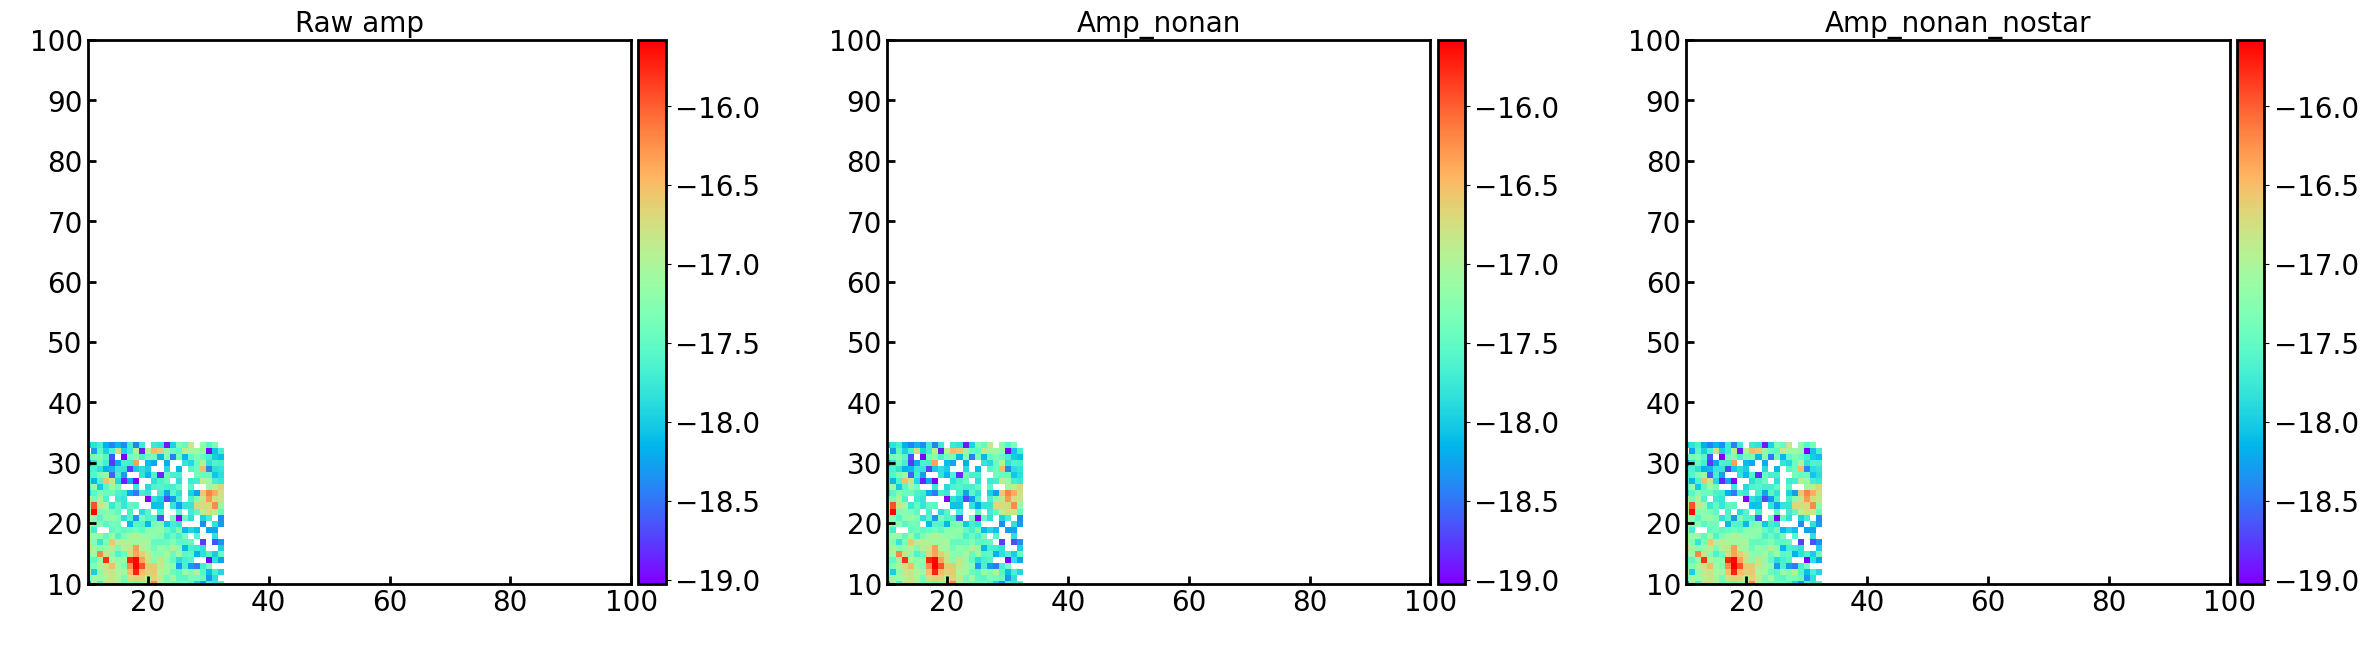

In [442]:
def makeplot(log,col,imagein,imagevvi,xi,xf,yi,yf,a,vvimin,vvimax):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='in',   labelsize=20, length=6, width=2)
    plt.axis([xi,xf,yi,yf])
    couleur = 'rainbow'
    if col==0: couleur = 'gray'
    if log == 1: 
        vvi=np.log10(imagevvi[yi:yf,xi:xf])
        plt.imshow(np.log10(imagein), cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if log != 1: 
        vvi=imagevvi[yi:yf,xi:xf]
        plt.imshow(imagein, cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if col !=0 : 
        cbar=plt.colorbar(pad=0.01)
        cbar.ax.tick_params(labelsize=20)
        #ax.set_xlabel('RA',size=20)
        #ax.set_ylabel('DEC',size=20)
        ax.update({'xlabel': ' ', 'ylabel': ' '})
        #plt.xlabel(' ',size=25)
        #plt.ylabel('DEC',size=25)
    return

# amp = fits.getdata(directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude.fits'.format(field))
amp = fits.getdata(amp_path)

xp1,xp2,yp1,yp2 = xi,xf,yi,yf
xp1,xp2,yp1,yp2 = 10,200,10,200
xp1,xp2,yp1,yp2 = 10,100,10,100

nyy, nxx, ip = 3,3,0
fig1 = plt.figure(figsize=(10*nxx,8*nyy))
fig1.subplots_adjust(hspace=0.2,wspace=0.1)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
makeplot(1,1,amp,amp,xp1,xp2,yp1,yp2,1,1,99.9)
plt.title('Raw amp',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
makeplot(1,1,amp_e_map,amp,xp1,xp2,yp1,yp2,1,1,99.9)
plt.title('Amp_nonan',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
makeplot(1,1,amp_m_map,amp,xp1,xp2,yp1,yp2,1,1,99.9)
plt.title('Amp_nonan_nostar',size=20)


noise  = fits.getdata(noi_path)
# amp_err  = fits.getdata(directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude-err.fits'.format(field))

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,noise,noise,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Raw noise',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,noi_e_map,noise,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Noise_nonan',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,noi_m_map,noise,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Noise_nonan_nostar',size=20)
          
# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,amp_err,amp_err,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Raw amp_err',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# plt.imshow(noise[yp1:yp2,xp1:xp2]/amp_err[yp1:yp2,xp1:xp2],origin='lower') 
# cbar=plt.colorbar(pad=0.01)
# cbar.ax.tick_params(labelsize=20)
# plt.title('Noise/orcs_err',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(0,1,sta_map,sta_map,xp1,xp2,yp1,yp2,1,0,10)
# plt.title('Star_map',size=20)


# print('If your Amp_nonan_nostar was long to calculate and your map looks strange,')
# print('check if your star_mask is reverse (0 instead of 1).')
# print('If so, go up and change the if condition. Also change condition below')
# print()
# print('If you have a lot of nan in your amp-err raw image,')
# print('maybe this should be use to remove the nan in the amp raw image, prior to Step1?')
# print()
# print('The ratio noise/orcs_err should be close to 1, if not ???')


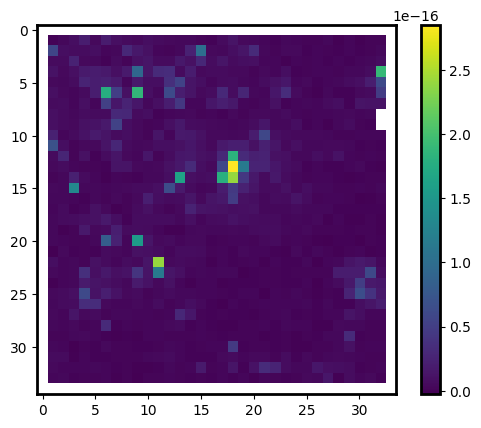

In [443]:
plt.imshow(amp)
plt.colorbar()

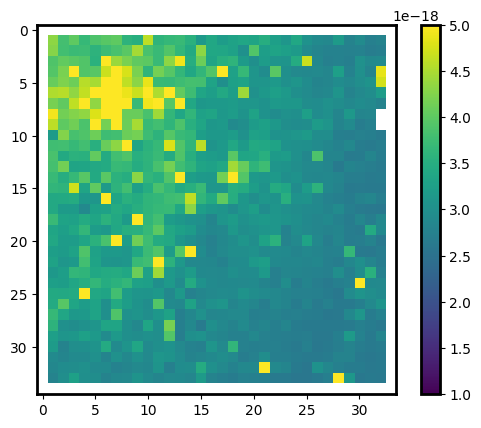

In [444]:
plt.imshow(noise, vmin=1e-18, vmax=5e-18)
plt.colorbar()

Text(0.5, 1.0, 'Amp nonan nostar')

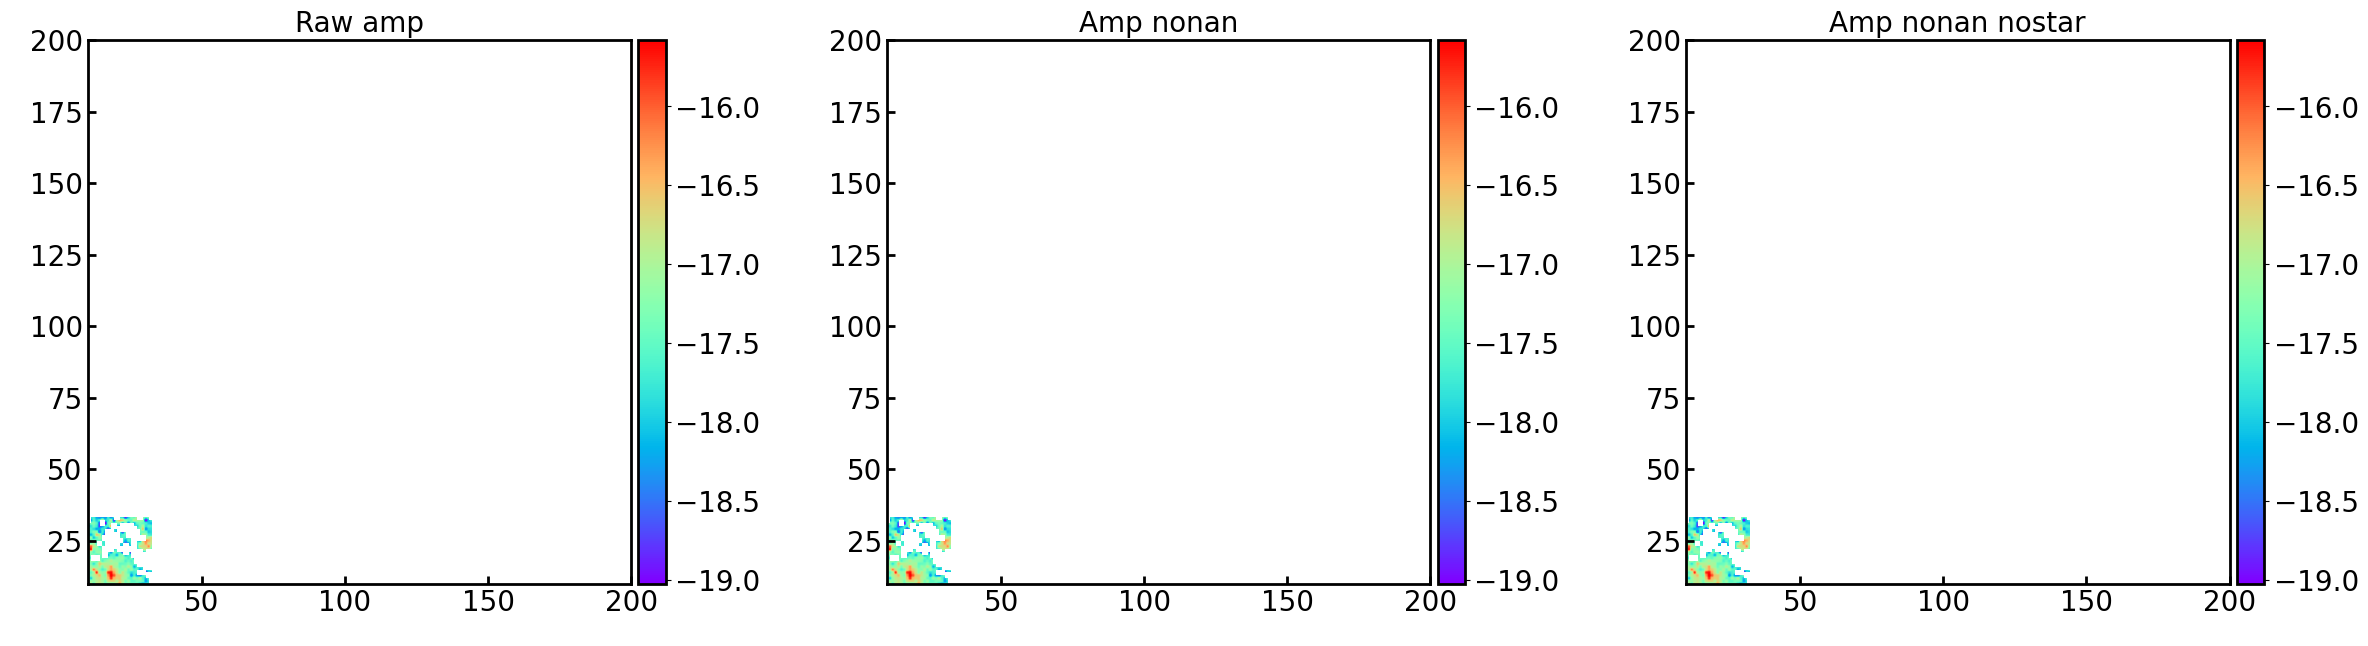

In [445]:
def makeplot(log,col,imagein,imagevvi,xi,xf,yi,yf,a,vvimin,vvimax):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='in',   labelsize=20, length=6, width=2)
    plt.axis([xi,xf,yi,yf])
    couleur = 'rainbow'
    if col==0: couleur = 'gray'
    if log == 1: 
        vvi=np.log10(imagevvi[yi:yf,xi:xf])
        plt.imshow(np.log10(imagein), cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if log != 1: 
        vvi=imagevvi[yi:yf,xi:xf]
        plt.imshow(imagein, cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if col !=0 : 
        cbar=plt.colorbar(pad=0.01)
        cbar.ax.tick_params(labelsize=20)
        #ax.set_xlabel('RA',size=20)
        #ax.set_ylabel('DEC',size=20)
        ax.update({'xlabel': ' ', 'ylabel': ' '})
        #plt.xlabel(' ',size=25)
        #plt.ylabel('DEC',size=25)
    return
    
xp1,xp2,yp1,yp2 = xi,xf,yi,yf
xp1,xp2,yp1,yp2 = 10,200,10,200

nyy, nxx, ip = 3,3,0
fig1 = plt.figure(figsize=(10*nxx,8*nyy))
fig1.subplots_adjust(hspace=0.2,wspace=0.1)

# amp  = fits.getdata('/arc/home/emmajarvis/M33/M33-F5/M33_Field5_SN3.LineMaps.map.6563.1x1.amplitude.fits')
ip=ip+1
ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
makeplot(1,1,amp,amp_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
plt.title('Raw amp',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
makeplot(1,1,amp_e_map,amp_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
plt.title('Amp nonan',size=20)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
makeplot(1,1,amp_m_map,amp_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
plt.title('Amp nonan nostar',size=20)

# # amp_err = fits.getdata('/arc/home/emmajarvis/M33/M33-F5/M33_Field5_SN3.LineMaps.map.6563.1x1.amplitude-err.fits')
# # noi     = fits.getdata('/arc/home/emmajarvis/M33/M33-F5/M33F5-Haflux-err.fits')
# noi = noise
# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,noi,noi_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Raw noise',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,noi_e_map,noi_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Noise nonan',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,noi_m_map,noi_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Noise nonan nostar',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(1,1,amp_err,noi_m_map,xp1,xp2,yp1,yp2,1,1,99.9)
# plt.title('Amp_err ORBS',size=20)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(0,1,amp_err/noi,amp_err/noi,xp1,xp2,yp1,yp2,1,0,100)
# plt.title('Amp_err ORBS/Raw noise',size=20)

## SNR for Ha_amp in a 3x3 box as a standard (do not depend on detection box size)
### Stars are replaced by median in intial files, and NAN in final file
### Edges are NAN in final file

In [446]:
       
sbox = 3

print('Creating SNR_(Ha amplitude) map with box =',str(sbox))
amp3 = np.copy(amp_m_map)
noi3 = np.copy(noi_m_map)
amp3[yi:yf,xi:xf] = uniform_filter(amp_m_map[yi:yf,xi:xf],   size=(sbox,sbox))  # must not contain NAN
noi3[yi:yf,xi:xf] = uniform_filter(noi_m_map[yi:yf,xi:xf]**2,size=(sbox,sbox))  # must not contain NAN
snr3     = amp3/np.sqrt(noi3)
snr3_fin = makefinal(1,snr3)

file     = f'{Folder_u}SNR{sbox}.fits'
fits.writeto(file, snr3_fin, header_info, overwrite=True)
print('Copying: ', file)
print('All done') 

Creating SNR_(Ha amplitude) map with box = 3
Copying:  data_for_visualisation_50/SNR3.fits
All done


In [447]:
# nyy, nxx, ip = 3,3,0
# fig1 = plt.figure(figsize=(10*nxx,8*nyy))
# fig1.subplots_adjust(hspace=0.2,wspace=0.1)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip) #,projection=wcs3)
# makeplot(0,1,snr3_fin,snr3_fin,xp1,xp2,yp1,yp2,1,0,100)
# plt.title('SNR3',size=20)


## Laplacian maps and Peak detections with the Amplitude (and the Flux map)
### These are automaticlay calculated for sigma_Laplacian from 1 to 2 with a step of 0.1
### Isolated peaks and peaks found for a positive Laplacian/Slope are rejected
### Stars are kept in intial files, and replaced by 0 in final peak file
### Edges are replaced by 0 in final peak file

In [448]:
# ajust to star_mask below

def get_laplacian_peak(amp, sigma, filep=''):
    laplacian = np.copy(amp)   ##amp has NAN outside x1,x2,y1,y2
    laplacian[yi:yf,xi:xf] = gaussian_laplace(amp[yi:yf,xi:xf], sigma)
    fits.writeto(f'{Folder_u}{filep}Lap{int(sigma*10):02}.fits', laplacian, header_info, overwrite=True)
    pic_map = local_min_lap_slo(laplacian)
    fits.writeto(f'{Folder_u}{filep}PicL{int(sigma*10):02}_sizd{sizedet}.fits', pic_map, header_info, overwrite=True)
    print('Sigma_lap: ',int(sigma*10)/10, '  -  Number of peaks: ',np.nansum(pic_map[yi:yf,xi:xf]))
    return

def local_min_lap_slo(lap_slo):       #### to be used both by the slope and the Lapacian 
    min_im              = np.copy(lap_slo)
    min_im[yi:yf,xi:xf] = minimum_filter(lap_slo[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1))
    min_y,min_x         = np.where((lap_slo - min_im) == 0)
    imapic              = np.zeros(lap_slo.shape) 
    imapic[min_y,min_x] = 1
    imapic[lap_slo  >= 0] = 0         #### keep only peaks if laplaccian/slope is negative
    yp,xp  = np.where(imapic == 1)    #### keep only peaks that are not isolated
    for i in range(len(xp)):
        if (np.count_nonzero((lap_slo[yp[i]-1:yp[i]+2,xp[i]-1:xp[i]+2]) >= 0) == 8 ): imapic[yp[i],xp[i]]=0
    imapic_fin=makefinal(0,imapic) 
    return(imapic_fin)

print('Creating Laplacian maps and detecting peaks with the amplitude map')
[get_laplacian_peak(amp_e_map, ii, filep='A_') for ii in np.arange(1, 2.1, 0.1)];
print('Creating:', f'{Folder_u}A_Lap[sigma].fits')
print('Creating:', f'{Folder_u}A_PicL[sigma]_sizd{sizedet}.fits')

print()
# print('Creating Laplacian maps and detecting peaks with the flux map')
# [get_laplacian_peak(flu_e_map, ii, filep='F_') for ii in np.arange(1, 2.1, 0.1)];
# print('Creating:', f'{Folder_u}F_Lap[sigma].fits')
# print('Creating:', f'{Folder_u}F_PicL[sigma]_sizd{sizedet}.fits')

print('All done')

Creating Laplacian maps and detecting peaks with the amplitude map
Sigma_lap:  1.0   -  Number of peaks:  39.0
Sigma_lap:  1.1   -  Number of peaks:  35.0
Sigma_lap:  1.2   -  Number of peaks:  30.0
Sigma_lap:  1.3   -  Number of peaks:  24.0
Sigma_lap:  1.4   -  Number of peaks:  22.0
Sigma_lap:  1.5   -  Number of peaks:  20.0
Sigma_lap:  1.6   -  Number of peaks:  18.0
Sigma_lap:  1.7   -  Number of peaks:  16.0
Sigma_lap:  1.8   -  Number of peaks:  14.0
Sigma_lap:  1.9   -  Number of peaks:  14.0
Sigma_lap:  2.0   -  Number of peaks:  11.0
Creating: data_for_visualisation_50/A_Lap[sigma].fits
Creating: data_for_visualisation_50/A_PicL[sigma]_sizd1.fits

All done


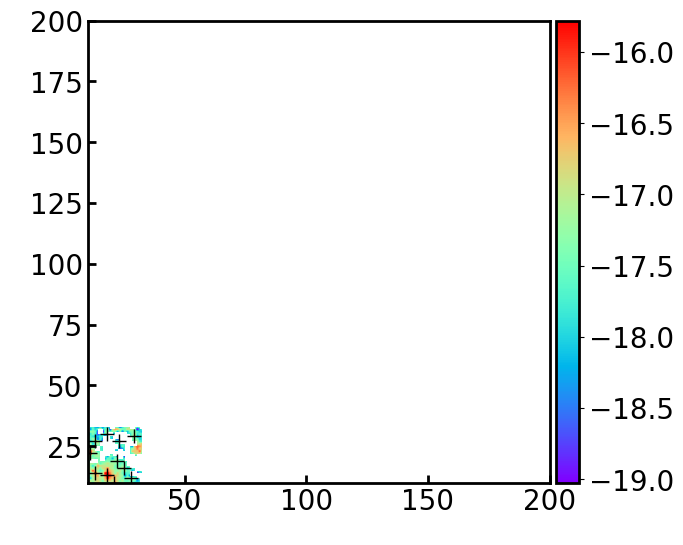

In [449]:
isig=15

nyy, nxx, ip = 1,1, 0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.15,wspace=0.1)

ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,amp_e_map,amp_e_map,xp1,xp2,yp1,yp2,1,1,99)
imapic = fits.getdata(f'data_for_visualisation_{distance}/A_PicL{isig}_sizd{sizedet}.fits')
ypic,xpic = np.where(imapic == 1)
ax.plot(xpic, ypic, '+',color='black',ms=10)



## Slope map and Peaks detection with the amplitude (and flux)
### It uses the same peak detection routine as for  Laplacian maps

In [450]:

def get_slope_peak(amp, filep=''):
    t = clock()
    file1 = f'{Folder_u}{filep}Slope_ring{nringslo}.fits'
    if os.path.isfile(file1):
        slope = fits.getdata(file1, header=False)
        print(file1, 'exists')
    else:
        mat=np.zeros((4,9,9))
        mat[3,0:9,0],mat[3,0:9,8],mat[3,0,0:9],mat[3,8,0:9]=1,1,1,1
        mat[2,1:8,1],mat[2,1:8,7],mat[2,1,1:8],mat[2,7,1:8]=1,1,1,1
        mat[1,2:7,2],mat[1,2:7,6],mat[1,2,2:7],mat[1,6,2:7]=1,1,1,1
        mat[0,3:6,3],mat[0,3:6,5],mat[0,3,3:6],mat[0,5,3:6]=1,1,1,1
        slope = np.copy(amp)
        slope[yi:yf,xi:xf] = 0
        
#        slope_e = np.copy(slope)
#        slope_r = np.copy(slope)
        t = clock()
        yr = np.arange(nringslo)*1.
        xr = np.arange(nringslo)+1.
        for i in range(yi,yf): 
            if i%300 == 0: print('  ',int(i*100/2064),'% done: ','%.2f seconds' %(clock()-t))
            for j in range(xi,xf): 
                imacut = amp[i-4:i+5,j-4:j+5]
                for ian in range(0,nringslo):
                    print(imacut.shape, mat.shape)
                    imacutt = imacut*mat[ian]
                    yr[ian] = np.nansum(imacutt)/np.count_nonzero(imacutt)
                output_linreg = stats.linregress(xr,yr) #slope, intercept, r_value, p_value, std_err 
                slope[i,j]    = output_linreg[0]
#                slope_e[i,j]  = output_linreg[-1]
#                slope_r[i,j]  = output_linreg[2]
        print('Time to create the slope map: %.2f seconds' %(clock()-t))
        fits.writeto(file1, slope, header_info, overwrite=True)
        print('Creating:', file1)            
    pic_map = local_min_lap_slo(slope)
    print('Number of rings: ',nringslo, '  -  Number of peaks: ',np.nansum(pic_map))
    file = f'{Folder_u}{filep}PicSlo_ring{nringslo}_sizd{sizedet}.fits'
    fits.writeto(file, pic_map, header_info, overwrite=True)
    print('Creating:', file)
    return
        
# print('Creating Slope map and detecting peaks with the amplitude map (takes time unless slope map exists)') 
get_slope_peak(amp_e_map, filep='A_')

#print()
# print('Creating Slope map and detecting peaks with the flux map (takes time unless slope map exists)')
# get_slope_peak(flu_e_map, filep='F_')

print('All done')


data_for_visualisation_50/A_Slope_ring3.fits exists
Number of rings:  3   -  Number of peaks:  25.0
Creating: data_for_visualisation_50/A_PicSlo_ring3_sizd1.fits
All done


In [451]:
# xp1,xp2,yp1,yp2 = 300,425,650,750

# nyy, nxx, ip = 1,1, 0
# fig1 = plt.figure(figsize=(8*nxx,6*nyy))
# fig1.subplots_adjust(hspace=0.15,wspace=0.1)

# ip=ip+1
# ax=plt.subplot(nyy,nxx,ip)
# makeplot(1,1,amp_e_map,amp_e_map,xp1,xp2,yp1,yp2,1,1,99)
# imapic = fits.getdata('data_for_visualisation/A_PicSlo_ring'+str(nringslo)+'_sizd'+str(sizedet)+'.fits')
# ypic,xpic = np.where(imapic == 1)
# ax.plot(xpic, ypic, '+',color='black',ms=10)

##  Files for the detection level using Amplitude 
###  BG box goes from 6 to 40 in step of 2 
###  Stars are replaced by median in initial files, but replaced by NAN in final files
###  Both orders of the operation (sizedet vs sizebg) are done here to check


In [452]:
def get_peak_emission(amp, filep=''): ### For some reason this can not be done with BG1 ???
    pkemis                = np.copy(amp)
    pkemis[yi:yf,xi:xf]   = uniform_filter(amp[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1))
    pkemis_fin            = makefinal(1,pkemis) 
    file = f'{Folder_u}{filep}sizd{sizedet}.fits'
    fits.writeto(file, pkemis_fin, header_info, overwrite=True)
    print('Creating:', file)
        
def get_bg_emission1(amp, filep=''):
    t = clock()
    pkemis                = np.copy(amp)
    pkemis[yi:yf,xi:xf]   = uniform_filter(amp[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1)) 
    bgemis                = np.copy(pkemis)
    for ibg in allbgbox:
        bgemis[yi:yf,xi:xf] = median_filter(pkemis[yi:yf,xi:xf],size=ibg)
        bgemis_fin          = makefinal(1,bgemis)
        fits.writeto(f'{Folder_u}{filep}sizd{sizedet}_sizbg{ibg}.fits', bgemis_fin, header_info, overwrite=True)
        print('BG box : ', ibg ,'%.2f seconds' %(clock()-t))
              
def get_bg_emission2(amp, filep=''):
    t = clock()
    bgemis1                  = np.copy(amp)
    for ibg in allbgbox:
        bgemis1[yi:yf,xi:xf] = median_filter(amp[yi:yf,xi:xf],size=ibg)
        bgemis               = np.copy(bgemis1)
        bgemis[yi:yf,xi:xf]  = uniform_filter(bgemis1[yi:yf,xi:xf],size=(sizedet*2+1,sizedet*2+1))
        bgemis_fin = makefinal(1,bgemis)
        fits.writeto(f'{Folder_u}{filep}sizd{sizedet}_sizbg{ibg}.fits', bgemis_fin, header_info, overwrite=True)
        print('BG box : ', ibg ,'%.2f seconds' %(clock()-t))



    
        
allbgbox=np.arange(6,42,2)

print('Creating Data signal as mean in detection box') 
get_peak_emission(amp_m_map, filep='AMP_')  #sta_map, xmin,xmax,ymin,ymax, sizedet, filep='AMP_') 

print()
print('Creating BG1 signal 1st as mean in detection box and 2nd as median in all larger boxes (it takes time...)')
get_bg_emission1(amp_m_map, filep='BG1_') 
print('Creating:',f'{Folder_u}BG1_sizd{sizedet}_sizbg[allbgbox].fits')

print()
print('Creating BG2 signal 1st as median in all larger boxes and 2nd as mean in detection box (it takes time...)')
get_bg_emission2(amp_m_map, filep='BG2_')
print('Creating:',f'{Folder_u}BG2_sizd{sizedet}_sizbg[allbgbox].fits')

print('All done')



Creating Data signal as mean in detection box
Creating: data_for_visualisation_50/AMP_sizd1.fits

Creating BG1 signal 1st as mean in detection box and 2nd as median in all larger boxes (it takes time...)
BG box :  6 0.00 seconds
BG box :  8 0.01 seconds
BG box :  10 0.01 seconds
BG box :  12 0.01 seconds
BG box :  14 0.02 seconds
BG box :  16 0.02 seconds
BG box :  18 0.02 seconds
BG box :  20 0.03 seconds
BG box :  22 0.03 seconds
BG box :  24 0.04 seconds
BG box :  26 0.05 seconds
BG box :  28 0.06 seconds
BG box :  30 0.07 seconds
BG box :  32 0.08 seconds
BG box :  34 0.09 seconds
BG box :  36 0.10 seconds
BG box :  38 0.11 seconds
BG box :  40 0.13 seconds
Creating: data_for_visualisation_50/BG1_sizd1_sizbg[allbgbox].fits

Creating BG2 signal 1st as median in all larger boxes and 2nd as mean in detection box (it takes time...)
BG box :  6 0.00 seconds
BG box :  8 0.00 seconds
BG box :  10 0.00 seconds
BG box :  12 0.01 seconds
BG box :  14 0.01 seconds
BG box :  16 0.01 seconds
BG

## Final input file,  with parameters and name files,  for visualisation

In [453]:
init_line = f'''import numpy as np
from astropy.io import fits


Cube_sel    = {cub_sel}
HST_sel     = {hst_sel} 
Velo_sel    = {vel_sel}
Sigma_sel   = {sig_sel}
S2hasig_sel = {shs_sel}

# Paths
path_data      = '{Folder_u}'
path_amp_nonan = '{amp_nonan_path}' 
path_cube      = '{cub_path}'
path_sky       = '{sky_path}'
path_hst_1     = '{hst_vi_path}'
path_hst_2     = '{hst_ha_path}'
path_velo      = '{vel_path}'
path_sigma     = '{sig_path}'
path_s2hasig   = '{shs_path}'
path_coord     = '{coo_path}'
    
# Central position (in pixel) of SITELLE FoV
x_cengal = {xcen}
y_cengal = {ycen}

ximin, ximax, yimin, yimax = {xi}, {xf}, {yi}, {yf}

# Local emission size
lista_les  = np.array({repr(localemis_range.tolist())})

# Laplacian range
laplacian_range = np.array({repr(np.round(lapsigma_range.tolist(), 2).tolist())})

# SNR map
imagen_SNR = f'data_for_visualisation_{distance}/SNR3.fits'

size = {sizedet}

nbring_ = '{nringslo}'

'''

with open(f'{Folder_u}/{rootout}_{sizedet}.py', 'w') as f:
    f.write(init_line)
    
print(init_line)


import numpy as np
from astropy.io import fits


Cube_sel    = False
HST_sel     = False 
Velo_sel    = False
Sigma_sel   = False
S2hasig_sel = False

# Paths
path_data      = 'data_for_visualisation_50/'
path_amp_nonan = 'data_for_visualisation_50/M33_amp_nonan.fits' 
path_cube      = ''
path_sky       = ''
path_hst_1     = ''
path_hst_2     = ''
path_velo      = ''
path_sigma     = ''
path_s2hasig   = ''
path_coord     = '../Final-Region-Identification/degraded-fits/NW/NW_amp_sim_50Mpc.fits'
    
# Central position (in pixel) of SITELLE FoV
x_cengal = 16
y_cengal = 16

ximin, ximax, yimin, yimax = 1, 32, 1, 32

# Local emission size
lista_les  = np.array([22, 26, 30, 34, 38])

# Laplacian range
laplacian_range = np.array([1.2, 1.4, 1.5, 1.6, 1.7, 1.8, 2.0])

# SNR map
imagen_SNR = f'data_for_visualisation_50/SNR3.fits'

size = 1

nbring_ = '3'




### Now you run 2-Visualisation_tool.py (or prepare files for another size of the peak detection box)

In [454]:
print('All done')

All done
